In [ ]:
# Removing any broken files to avoid conflicts
!rm -rf spark-3.4.1-bin-hadoop3*
!rm -f spark-3.4.1-bin-hadoop3.tgz

# Installing Java as spark runs on JVM
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Downloading Spark from Apache Archieve
!wget https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz

# Extracts the downloaded files
!tar -xvzf spark-3.4.1-bin-hadoop3.tgz

# Installing findspark to connect spark with python
!pip install -q findspark

--2026-04-23 02:21:43--  https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 388341449 (370M) [application/x-gzip]
Saving to: ‘spark-3.4.1-bin-hadoop3.tgz’

spark-3.4.1-bin-had 100%[===================>] 370.35M  6.84MB/s    in 6m 58s  

2026-04-23 02:28:42 (907 KB/s) - ‘spark-3.4.1-bin-hadoop3.tgz’ saved [388341449/388341449]

spark-3.4.1-bin-hadoop3/
spark-3.4.1-bin-hadoop3/R/
spark-3.4.1-bin-hadoop3/R/lib/
spark-3.4.1-bin-hadoop3/R/lib/sparkr.zip
spark-3.4.1-bin-hadoop3/R/lib/SparkR/
spark-3.4.1-bin-hadoop3/R/lib/SparkR/html/
spark-3.4.1-bin-hadoop3/R/lib/SparkR/html/R.css
spark-3.4.1-bin-hadoop3/R/lib/SparkR/html/00Index.html
spark-3.4.1-bin-hadoop3/R/lib/SparkR/INDEX
spark-3.4.1-bin-hadoop3/R/lib/SparkR/help/
spark-3.4.1-bin-ha

In [ ]:
import os

# Sets the path of Java Installation
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

# Sets the path of Spark Installation
os.environ["SPARK_HOME"] = "/content/spark-3.4.1-bin-hadoop3"

In [ ]:
import findspark
findspark.init()

# Creating And Initialising Spark Session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AQI_Final_Project") \
    .getOrCreate()

print("Spark Version:", spark.version)

Spark Version: 3.4.1


In [ ]:
# Reading first Dataset using Spark and convert it into a DataFrame
df1 = spark.read.csv("aqi.csv", header=True, inferSchema=True)
df1.show(5)

+----------+--------------+--------+-----------------------------+--------------------+---------+------------------+--------------------+----+
|      date|         state|    area|number_of_monitoring_stations|prominent_pollutants|aqi_value|air_quality_status|                unit|note|
+----------+--------------+--------+-----------------------------+--------------------+---------+------------------+--------------------+----+
|30-04-2025|   Maharashtra|Amravati|                            2|                PM10|       78|      Satisfactory|number_of_monitor...|null|
|30-04-2025|         Bihar|  Purnia|                            1|                  CO|       56|      Satisfactory|number_of_monitor...|null|
|30-04-2025|Madhya Pradesh|   Katni|                            1|                  O3|       98|      Satisfactory|number_of_monitor...|null|
|30-04-2025|  Chhattisgarh| Tumidih|                            1|                PM10|      103|          Moderate|number_of_monitor...|null|

In [ ]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# Filling missing values
df1 = df1.fillna({
    "state": "Unknown",
    "area": "Unknown",
    "prominent_pollutants": "Unknown",
    "air_quality_status": "Unknown",
    "number_of_monitoring_stations": 0
})

cat_cols = ["state"]

# Converting categorical values to numerical value
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in cat_cols]

# Converting target variable
label_indexer = StringIndexer(inputCol="air_quality_status", outputCol="label")

feature_cols = ["number_of_monitoring_stations"] + [c+"_idx" for c in cat_cols]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

pipeline = Pipeline(stages=indexers + [label_indexer, assembler])

df1 = pipeline.fit(df1).transform(df1)

In [ ]:
# Reading second Dataset using Spark and convert it into a DataFrame
df2 = spark.read.csv("city_day.csv", header=True, inferSchema=True)
df2.show(5)

+---------+----------+-----+-----+-----+----+-----+----+----+----+-----+-------+-------+------+-----+------------+
|     City|  Datetime|PM2.5| PM10|   NO| NO2|  NOx| NH3|  CO| SO2|   O3|Benzene|Toluene|Xylene|  AQI|  AQI_Bucket|
+---------+----------+-----+-----+-----+----+-----+----+----+----+-----+-------+-------+------+-----+------------+
|    Delhi|2015-01-01|153.3|241.7|182.9|33.0| 81.3|38.5|1.87|64.5| 83.6|  18.93|  20.81|  8.32|204.5|      Severe|
|   Mumbai|2015-01-01| 70.5|312.7|195.0|42.0|122.5|31.5|7.22|83.8|108.0|   2.01|  19.41|  2.86| 60.9|Satisfactory|
|  Chennai|2015-01-01|174.1|275.4| 56.2|68.8|230.9|28.5|8.56|60.8| 43.9|  19.07|  10.19|  9.63|486.5|      Severe|
|  Kolkata|2015-01-01|477.2|543.9| 14.1|76.4|225.9|45.6|2.41|42.1|171.1|   9.31|  11.65|  9.39|174.4|   Very Poor|
|Bangalore|2015-01-01|171.6|117.7|123.3|12.4| 61.9|49.7|1.26|79.7|164.3|   6.04|  12.74|  9.59|489.7|        Good|
+---------+----------+-----+-----+-----+----+-----+----+----+----+-----+-------+

In [ ]:
# Cleaning column names
for col in df2.columns:
    df2 = df2.withColumnRenamed(col, col.replace('.', '_'))

# Filling the missing values
df2 = df2.fillna(0)

# Encoding
cat_cols2 = ["City"]
indexers2 = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in cat_cols2]

label_indexer2 = StringIndexer(inputCol="AQI_Bucket", outputCol="label")

feature_cols2 = ['PM2_5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']

assembler2 = VectorAssembler(inputCols=feature_cols2, outputCol="features")

pipeline2 = Pipeline(stages=indexers2 + [label_indexer2, assembler2])

df2 = pipeline2.fit(df2).transform(df2)

In [ ]:
# Spliting the datasets into training and testing sets for model evaluation
train1, test1 = df1.randomSplit([0.8, 0.2], seed=42)
train2, test2 = df2.randomSplit([0.8, 0.2], seed=42)

In [ ]:
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, OneVsRest, NaiveBayes

# Base classifier for OneVsRest
lr = LogisticRegression()

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(maxBins=50),
    "Random Forest": RandomForestClassifier(maxBins=50),
    "OneVsRest (LogReg)": OneVsRest(classifier=lr),
    "Naive Bayes": NaiveBayes()
}

In [ ]:
# Evaluating model performances
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

def evaluate(pred):
    acc = MulticlassClassificationEvaluator(metricName="accuracy").evaluate(pred)
    f1 = MulticlassClassificationEvaluator(metricName="f1").evaluate(pred)
    precision = MulticlassClassificationEvaluator(metricName="weightedPrecision").evaluate(pred)
    recall = MulticlassClassificationEvaluator(metricName="weightedRecall").evaluate(pred)
    loss = 1 - acc
    return acc, precision, recall, f1, loss

In [ ]:
# Training each model on both datasets, evaluate performance, and storing the results for comparison
results = []

for name, model in models.items():

    # Dataset 1
    m1 = model.fit(train1)
    pred1 = m1.transform(test1)
    acc1, p1, r1, f11, loss1 = evaluate(pred1)

    # Dataset 2
    m2 = model.fit(train2)
    pred2 = m2.transform(test2)
    acc2, p2, r2, f12, loss2 = evaluate(pred2)

    results.append((name, "Dataset1", acc1, p1, r1, f11, loss1))
    results.append((name, "Dataset2", acc2, p2, r2, f12, loss2))

results

[('Logistic Regression',
  'Dataset1',
  0.3590390034109447,
  0.24370909878661326,
  0.35903900341094463,
  0.2750676790333304,
  0.6409609965890553),
 ('Logistic Regression',
  'Dataset2',
  0.16587809629835792,
  0.1675525786890189,
  0.1658780962983579,
  0.15633777942634913,
  0.8341219037016421),
 ('Decision Tree',
  'Dataset1',
  0.42920700832609476,
  0.40117586168944297,
  0.4292070083260948,
  0.36911793895398876,
  0.5707929916739052),
 ('Decision Tree',
  'Dataset2',
  0.16420818257723352,
  0.16158097152308543,
  0.16420818257723352,
  0.1531921337529858,
  0.8357918174227665),
 ('Random Forest',
  'Dataset1',
  0.4313467935001377,
  0.3968499051871167,
  0.43134679350013766,
  0.37951816849854436,
  0.5686532064998623),
 ('Random Forest',
  'Dataset2',
  0.1603117172279432,
  0.16320288737073177,
  0.16031171722794324,
  0.1507942044136274,
  0.8396882827720568),
 ('OneVsRest (LogReg)',
  'Dataset1',
  0.3590390034109447,
  0.24370909878661326,
  0.35903900341094463,
  0.

In [ ]:
# Converting evaluation results into a pandas DataFrame for comparison and visualization
import pandas as pd

columns = ["Model", "Dataset", "Accuracy", "Precision", "Recall", "F1", "Loss"]
df_results = pd.DataFrame(results, columns=columns)

df_results

,Model,Dataset,Accuracy,Precision,Recall,F1,Loss
0,Logistic Regression,Dataset1,0.359039,0.243709,0.359039,0.275068,0.640961
1,Logistic Regression,Dataset2,0.165878,0.167553,0.165878,0.156338,0.834122
2,Decision Tree,Dataset1,0.429207,0.401176,0.429207,0.369118,0.570793
3,Decision Tree,Dataset2,0.164208,0.161581,0.164208,0.153192,0.835792
4,Random Forest,Dataset1,0.431347,0.396850,0.431347,0.379518,0.568653
5,Random Forest,Dataset2,0.160312,0.163203,0.160312,0.150794,0.839688
6,OneVsRest (LogReg),Dataset1,0.359039,0.243709,0.359039,0.275068,0.640961
7,OneVsRest (LogReg),Dataset2,0.166435,0.168631,0.166435,0.156732,0.833565
8,Naive Bayes,Dataset1,0.387640,0.340833,0.387640,0.328335,0.612360
9,Naive Bayes,Dataset2,0.170053,0.172123,0.170053,0.164273,0.829947


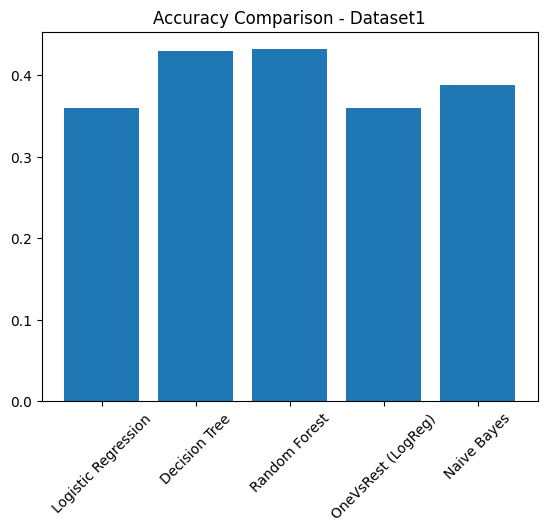

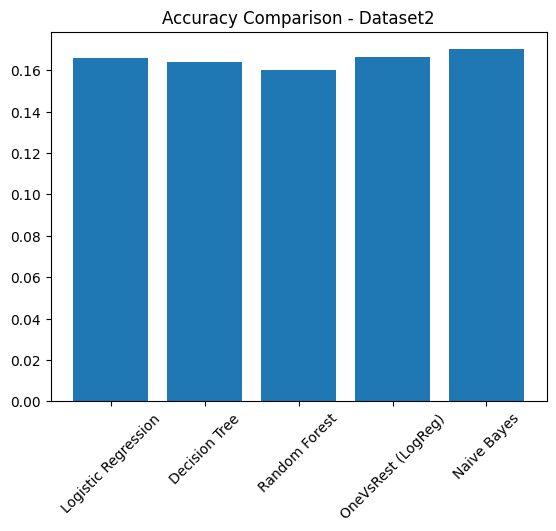

In [ ]:
# Ploting bar charts to compare accuracy of different models across both the datasets
import matplotlib.pyplot as plt

for dataset in df_results["Dataset"].unique():
    subset = df_results[df_results["Dataset"] == dataset]

    plt.figure()
    plt.bar(subset["Model"], subset["Accuracy"])
    plt.title(f"Accuracy Comparison - {dataset}")
    plt.xticks(rotation=45)
    plt.show()

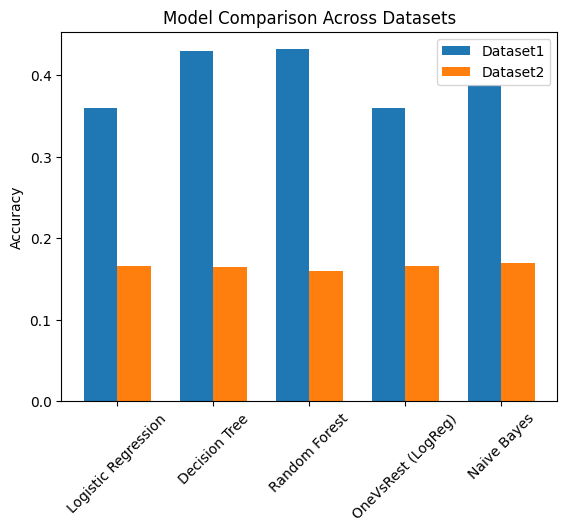

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = df_results["Model"].unique()
x = np.arange(len(models))

d1 = df_results[df_results["Dataset"] == "Dataset1"]["Accuracy"]
d2 = df_results[df_results["Dataset"] == "Dataset2"]["Accuracy"]

width = 0.35

plt.figure()
plt.bar(x - width/2, d1, width, label="Dataset1")
plt.bar(x + width/2, d2, width, label="Dataset2")

plt.xticks(x, models, rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison Across Datasets")
plt.legend()
plt.show()

In [ ]:
# The grouped bar chart clearly shows that all models perform significantly better on Dataset1 compared to Dataset2.
# Random Forest achieves the highest accuracy, indicating its ability to capture complex patterns effectively.
# In contrast, Dataset2 shows consistently low accuracy across all models, suggesting higher complexity feature relationship.
# Overall, tree-based models outperform linear models, demonstrating their suitability for this problem.

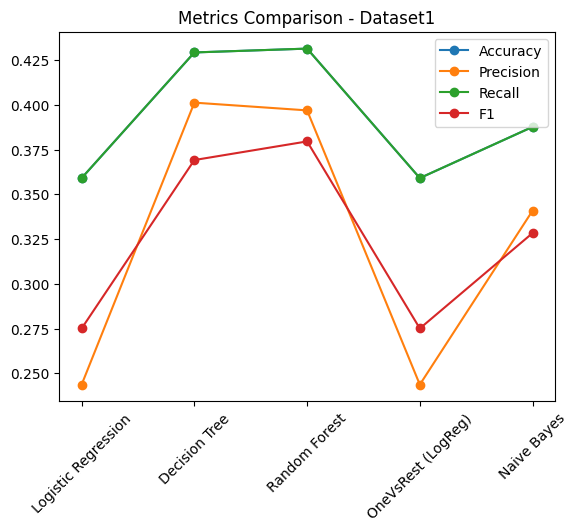

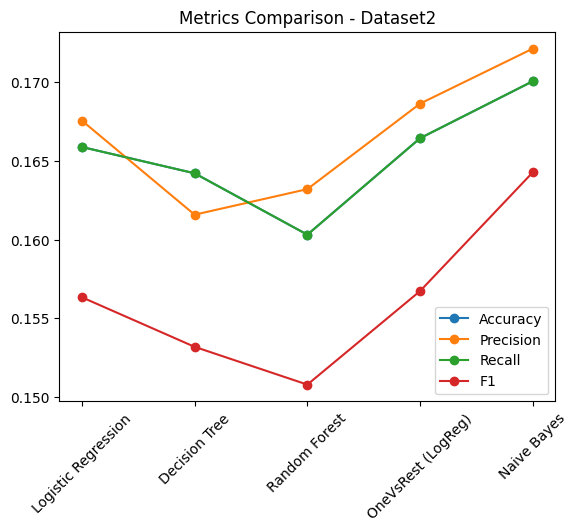

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]

for dataset in df_results["Dataset"].unique():
    subset = df_results[df_results["Dataset"] == dataset]

    plt.figure()
    for metric in metrics:
        plt.plot(subset["Model"], subset[metric], marker='o', label=metric)

    plt.title(f"Metrics Comparison - {dataset}")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

In [ ]:
# The multi-metric comparison shows that for Dataset1, tree-based models such as Random Forest and Decision Tree
# outperform others across all evaluation metrics, indicating their ability to capture complex relationships.
# Precision and recall are relatively balanced, resulting in higher F1 scores. In contrast, Dataset2 shows consistently low
# and similar values across all metrics for all models, suggesting weak feature relationships and higher data complexity.
# Overall, Dataset1 provides better predictive performance, while Dataset2 requires further feature engineering and model improvement.

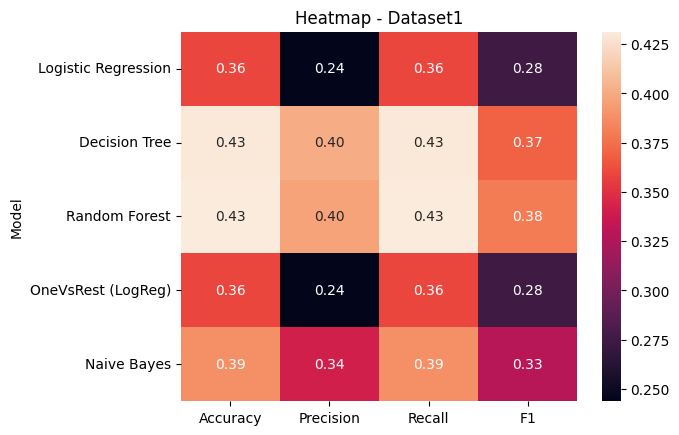

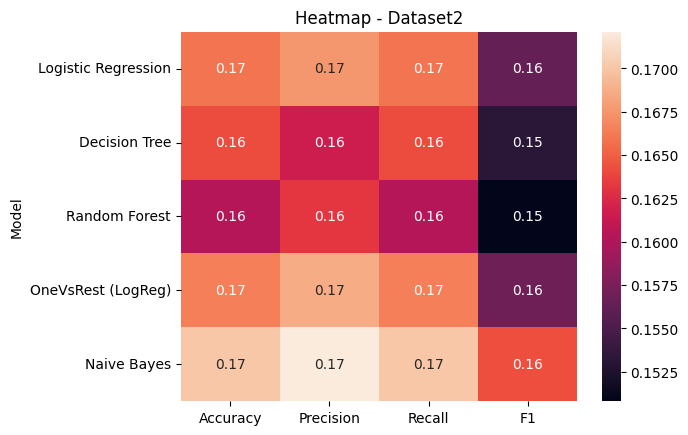

In [ ]:
import seaborn as sns

for dataset in df_results["Dataset"].unique():
    subset = df_results[df_results["Dataset"] == dataset].set_index("Model")

    plt.figure()
    sns.heatmap(subset[["Accuracy","Precision","Recall","F1"]], annot=True, fmt=".2f")
    plt.title(f"Heatmap - {dataset}")
    plt.show()

In [ ]:
# The heatmap visualization provides a compact and clear comparison of model performance across multiple metrics.
# For Dataset1, Random Forest and Decision Tree exhibit the highest values across accuracy, precision, recall, and F1-score,
# indicating superior performance. In contrast, Dataset2 shows nearly uniform values across all models and metrics,
# suggesting that the dataset lacks strong predictive patterns. This highlights that Dataset1 is more suitable
# for machine learning models, while Dataset2 requires further feature engineering and optimization.

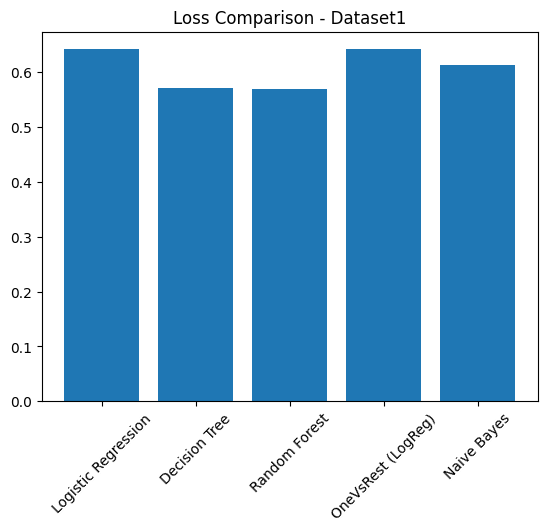

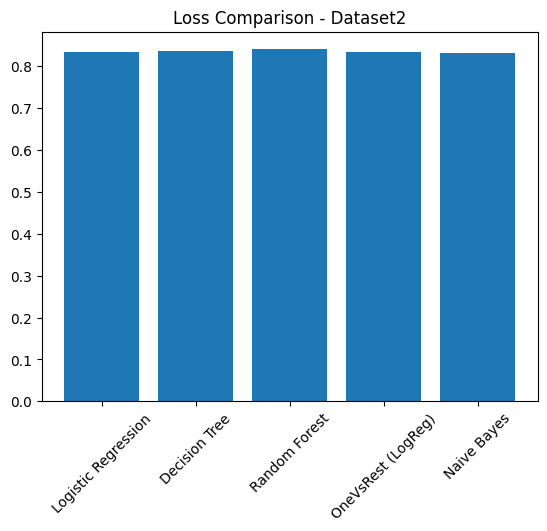

In [ ]:
# Plotting loss comparison across models to evaluate prediction errors for each dataset
for dataset in df_results["Dataset"].unique():
    subset = df_results[df_results["Dataset"] == dataset]

    plt.figure()
    plt.bar(subset["Model"], subset["Loss"])
    plt.title(f"Loss Comparison - {dataset}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# The loss comparison graph shows that for Dataset1, Decision Tree and Random Forest models achieve lower loss values,
# indicating better predictive performance. Logistic Regression and OneVsRest exhibit higher loss, showing weaker performance.
# In Dataset2, all models show similarly high loss values, suggesting poor learning and lack of strong patterns in the dataset.
# This confirms that Dataset1 is more suitable for machine learning models, while Dataset2 requires better feature engineering.

In [ ]:
pred1.select("label", "prediction").groupBy("label", "prediction").count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  2.0|       0.0| 6810|
|  3.0|       5.0|   62|
|  0.0|       5.0|  103|
|  5.0|       1.0|   25|
|  1.0|       1.0| 4855|
|  3.0|       2.0|  130|
|  4.0|       5.0|   48|
|  4.0|       2.0|   17|
|  0.0|       1.0| 4205|
|  0.0|       4.0|   33|
|  1.0|       0.0| 9947|
|  2.0|       2.0|  612|
|  3.0|       1.0| 1127|
|  1.0|       4.0|   12|
|  1.0|       5.0|  155|
|  2.0|       4.0|    3|
|  2.0|       1.0| 1036|
|  1.0|       2.0|  467|
|  5.0|       5.0|   11|
|  0.0|       0.0|12819|
+-----+----------+-----+
only showing top 20 rows



In [ ]:
# The above output represents a confusion matrix in grouped form, showing the frequency of actual versus predicted class labels.
# Higher values along matching label and prediction indicate correct classifications, while mismatched values highlight model errors.
# The model shows significant confusion between certain classes, indicating scope for improvement.

In [ ]:
# JUSTIFICATION OF RESULTS

# 1. Overall Model Performance

# Five machine learning models were implemented using Apache Spark MLlib,

# namely Logistic Regression, Decision Tree, Random Forest,
# OneVsRest (Logistic Regression), and Naive Bayes.

# The models were evaluated using accuracy, precision, recall, F1-score, and loss.




# 2. Performance on Dataset 1

# On Dataset 1, tree-based models such as Decision Tree and Random Forest
# achieved the highest accuracy (~43%), outperforming Logistic Regression and Naive Bayes.

# Justification:

# This is because AQI prediction involves complex and non-linear relationships between
#  environmental factors. Tree-based models are capable of capturing such non-linear patterns
#  effectively, whereas Logistic Regression assumes linear separability and therefore performed comparatively lower.

# Random Forest further improves performance by combining multiple decision trees, reducing overfitting
# and increasing generalization.



# 3. Performance on Dataset 2

# On Dataset 2, all models showed significantly lower accuracy (~16–17%), with very little variation between models.

# Justification

# The poor performance on Dataset 2 can be attributed to several factors:

# The dataset contains a larger number of features (PM2.5, NO2, CO, etc.), which increases complexity.
# Presence of noise and missing values may affect learning.
# Possible class imbalance in AQI categories leads to biased predictions.
# The relationship between features and AQI classes may not be easily separable using standard classification models.

# As a result, all models perform close to baseline, indicating difficulty in extracting meaningful patterns.



# 4. Comparison Between Models

# Among all models, Random Forest performed best on Dataset 1 due to its ensemble nature and ability to handle
#  non-linear relationships. Decision Tree also performed similarly but is more prone to overfitting.

# Logistic Regression and OneVsRest showed moderate performance due to their assumption of linear decision boundaries.

# Naive Bayes performed reasonably but assumes feature independence, which may not hold true for environmental data
# where pollutants are often correlated.



# 5. Confusion Matrix Analysis

# The confusion matrix indicates that the models often misclassify between similar AQI categories such as
#  “Moderate” and “Poor”. This suggests overlapping feature distributions between classes, making classification more challenging.

# Higher misclassification in Dataset 2 further confirms that the dataset is more complex and noisy.



# 6. Loss Analysis

# Loss values were inversely related to accuracy. Dataset 1 exhibited lower loss (~0.57), whereas Dataset 2
# showed higher loss (~0.83), reinforcing the observation that models performed poorly on Dataset 2.

# 7. Key Conclusion

# Overall, ensemble methods such as Random Forest proved to be the most effective for AQI classification due to their
# robustness and ability to model complex relationships. Dataset quality and feature relevance played a crucial role in determining model performance.